# Gradient-benchmark figures: oscillation decay and per-component amplitude vs N

Three figures built from the existing `data/bias_benchmarks/` checked-AE scans
(the same data behind `figs/grad_oscillations_chain_N*.pdf` and
`figs/grad_benchmark_decay_chain_N*.pdf`; see `code/plot_benchmark_decay.py`
and `code/sample_benchmark_windows.py`, which this notebook imports rather
than re-implementing their window-audit/statistics logic).

1. **Oscillation vanishing, N=1 vs N=5.** The individual per-N oscillation
   figures each autoscale their own y-axis, which hides how much smaller the
   stiff-schedule wiggle at N=5 actually is in absolute terms. Here both
   sizes share the y-limits set by N=1 (the largest oscillation), so the
   shrinkage is visible on one fixed scale instead of being disguised by
   autoscaling.
2. **All-N amplitude decay, $\Delta$ component.**
3. **All-N amplitude decay, $\Omega$ component.**

Figures 2 and 3 split the existing `grad_benchmark_decay_chain_N{N}.pdf`
panels (a)/(b) out by component and combine all five chain sizes into one
plot each (mirroring how `grad_benchmark_decay_chains.pdf` already combines
sizes for the total RMS error), using the same $N\to$colour ramp in both
figures so a given $N$ is recognizable across them.

Inputs are the existing files in `data/bias_benchmarks_deep/`; no new
training, remote jobs, or downloads are performed. Set `SAVE_FIGURES = False`
in the setup cell to preview without writing PDFs/PNGs.

**Cost operator and point (applies to every figure here).** All data in this
notebook is the **squared staggered magnetisation** cost
$\mathrm{AM}^2$, with $\mathrm{AM}=\frac{1}{N}\sum_k(-1)^k\sigma^z_k$ --
built by `Ising_Chain_AM2` and selected with
`sample_benchmark_windows.py --cost AM2` -- evaluated at
$(\Omega,\Delta)=(1.0,1.0)$ and recorded as `cost='AM2'` in every input file's
metadata.

**Why $N=1$ is absent.** For a single atom $\mathrm{AM}=\sigma^z$, so
$\mathrm{AM}^2=\mathbb{1}$ *exactly*: $\langle\mathrm{AM}^2\rangle=1$ in every
state, the loss is constant, and the gradient vanishes identically (verified:
the exact estimator returns $(0,0)$, and the project's own
`data/bias/bias_chain_N1_AM2.npz` stores `g_ED = [0, 0]`). There is therefore
no oscillation to measure at $N=1$ under $\mathrm{AM}^2$, and the sizes shown
here start at $N=3$; `sample_benchmark_windows.py` refuses the
`--N 1 --cost AM2` combination outright rather than writing a file of zeros.

The corresponding **AM** (linear) figures, where $N=1$ *is* meaningful and
nonzero, are kept alongside these under their original filenames; the
$\mathrm{AM}^2$ outputs of this notebook all carry an `_AM2` suffix.


## Setup and figure style

In [13]:
from pathlib import Path
import os
import sys
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter
from IPython.display import display

%matplotlib inline

# Locate paper_figs when launched from this folder, AFM_searching, or the repo.
candidates = []
for parent in (Path.cwd(), *Path.cwd().parents):
    candidates.extend((parent, parent / "paper_figs", parent / "AFM_searching" / "paper_figs"))
PAPER = next((p for p in candidates
              if (p / "code" / "figstyle.py").is_file()
              and (p / "data" / "bias_benchmarks").is_dir()), None)
if PAPER is None:
    raise FileNotFoundError("Open this notebook from inside the QEP_sparse checkout.")

# "deep" (Omega=1.0, Delta=1.0): the base point (1.0, 2.6) has a near-zero exact
# gradient, which makes the raw-oscillation figure hard to read. The _AM2 tree is
# the AM^2 cost operator (Ising_Chain_AM2); N=1 is absent there by construction,
# since AM=sigma^z for one atom makes AM^2 the identity and the gradient zero.
DATA = PAPER / "data" / "bias_benchmarks_deep_AM2"
# Optional environment override is useful for checking plots without replacing originals.
FIGS = Path(os.environ.get("AFM_NOTEBOOK_FIGURE_ROOT", str(PAPER / "figs")))
SAVE_FIGURES = True  # False: display figures inline without writing PDFs/PNGs.

sys.path.insert(0, str(PAPER / "code"))


def load_module(name, filename):
    spec = importlib.util.spec_from_file_location(name, PAPER / "code" / filename)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


F = load_module("afm_paper_figstyle", "figstyle.py")
SBW = load_module("afm_paper_sample_benchmark_windows", "sample_benchmark_windows.py")
# plot_benchmark_decay.py only runs its CLI under __main__, so importing it just
# gives us the validated window-loading / statistics / drawing helpers.
PBD = load_module("afm_paper_plot_benchmark_decay", "plot_benchmark_decay.py")
F.use_style()


def read(path):
    with np.load(path, allow_pickle=False) as d:
        return {k: d[k].copy() for k in d.files}


def save(fig, path):
    """Display the editable plot, optionally writing the usual PDF and PNG."""
    if SAVE_FIGURES:
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight")
        fig.savefig(path.with_suffix(".png"), dpi=170, bbox_inches="tight")
        print("wrote", path.relative_to(FIGS))
    display(fig)
    plt.close(fig)


print("Data:", DATA)
print("Figures:", FIGS)


Data: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/data/bias_benchmarks_deep_AM2
Figures: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/figs


## Load the checked benchmark windows

Reuses `plot_benchmark_decay.load_windows`, which validates each benchmark's
stored statistics against a fresh recomputation and folds in the window-
stability audit (the N=5/T=500 and N=9/T=20 "hollow marker" caution flags)
before anything is plotted.


In [14]:
# N=1 has an identically zero AM^2 gradient, so it is excluded here. PBD.NS is
# the module-level list that load_windows / common_benchmarks / shared_decay_limits
# all iterate, so it has to be narrowed before they run.
PBD.NS = NS = (3, 5, 7, 9)
windows, summary = PBD.load_windows(DATA)
SCHEDULES = SBW.SCHEDULES
display_T = PBD.common_benchmarks(windows)
ylimits = PBD.shared_decay_limits(windows, display_T)   # [Omega, Delta, total] (lo, hi) pairs
xlimits = (min(display_T) / 1.25, max(display_T) * 1.25)
N_colors = dict(zip(NS, F.ramp_colors(len(NS))))  # same N -> colour map used in figures 2 and 3

print("Chain sizes:", NS)
print("Shared completed benchmarks:", display_T)


Chain sizes: (3, 5, 7, 9)
Shared completed benchmarks: [20, 50, 100, 200, 500, 1000, 2000]


## 1. Oscillation vs system size, $N=3,5,7,9$, dense to $T=500$

Continuous dense traces (smooth ramp, stiff ramp, ED reference) for all four
$\mathrm{AM}^2$ sizes. This replaces the earlier $N=3$ vs $N=5$, $T\le200$
version, which showed too little contrast over too short a range.

The scan is $T\in[0.25,\,500]$ at step $0.5$ — 1000 points per size, per
schedule. The step is justified rather than assumed: the dominant oscillation
period, measured by FFT of the existing benchmark windows, is $6.75$ ($N=3$),
$4.05$ ($N=5$) and $5.06$ ($N=7$ and $N=9$), so $0.5$ gives 8–13 samples per
period everywhere. It does *not* keep shrinking with $N$, which is why one
step size serves all four sizes.

Cost grows with $T$ (each sample is a full evolution to time $T$), so the run
was split into 8 **equal-cost** chunks per size — boundaries placed on
cumulative $T$, each carrying 12.4–12.6% of the work — and run as 32 parallel
cluster tasks. The chunks concatenate into a gap-free uniform grid (verified:
step exactly $0.5$, no duplicates). $N=9$ alone would have taken ~1.6 h
serially; the whole set finished in minutes.

The vertical scale is shared along each row across all four sizes. It cannot
be keyed to the smallest $N$ here: under $\mathrm{AM}^2$ the *larger* sizes
carry the *larger* oscillation, the opposite of the AM case where $N=1$
dominated, so keying to $N=3$ would clip $N=5,7,9$.


In [15]:
SCHEDULES

('smooth', 'stiff')

In [16]:
plot_SCHEDULES = ('stiff', 'smooth')

points per size: {3: 1000, 5: 1000, 7: 1000, 9: 1000} | T range: 0.25..499.75
wrote grad_oscillation_AM2_allN_long.pdf


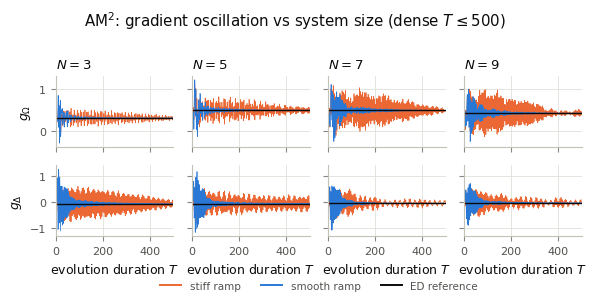

In [17]:
import glob

EX_NS = (3, 5, 7, 9)
LONG = PAPER / "data" / "bias_benchmarks_deep_AM2_long"

def load_long(N):
    """Concatenate the 8 equal-cost T-chunks into one gap-free trace."""
    parts = [read(f) for f in sorted(glob.glob(str(LONG / f"benchmark_chain_N{N}_*.npz")))]
    order = np.argsort(np.concatenate([p["TL"] for p in parts]))
    out = {"TL": np.concatenate([p["TL"] for p in parts])[order],
           "g_ED": parts[0]["g_ED"]}
    for s in plot_SCHEDULES:
        out[f"g_{s}_AE"] = np.concatenate([p[f"g_{s}_AE"] for p in parts])[order]
    step = np.diff(out["TL"])
    assert np.allclose(step, step[0]) and len(np.unique(out["TL"])) == len(out["TL"]), \
        f"N={N}: chunks do not form a uniform gap-free grid"
    return out

raws = {N: load_long(N) for N in EX_NS}
print("points per size:", {N: len(raws[N]["TL"]) for N in EX_NS},
      "| T range:", f'{raws[3]["TL"][0]:.2f}..{raws[3]["TL"][-1]:.2f}')

# One y-scale per row over *all* sizes: under AM^2 the larger N oscillate more,
# so keying the scale to the smallest N would clip the rest.
ycols = []
for j in range(2):
    vals = np.concatenate([raws[N][f"g_{s}_AE"][:, j] for N in EX_NS for s in plot_SCHEDULES]
                          + [[raws[N]["g_ED"][j]] for N in EX_NS])
    lo, hi = vals.min(), vals.max()
    pad = 0.06 * (hi - lo)
    ycols.append((lo - pad, hi + pad))

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(2, len(EX_NS), figsize=(6.0, 2.8), sharex=True, sharey="row")
    for col, N in enumerate(EX_NS):
        raw = raws[N]
        for j, symbol in enumerate((r"\Omega", r"\Delta")):
            ax = axes[j, col]
            for s in plot_SCHEDULES:
                ax.plot(raw["TL"], raw[f"g_{s}_AE"][:, j], color=F.SCHEDULE_COLOR[s], lw=0.5)
            ax.axhline(raw["g_ED"][j], color=F.INK, lw=1)
            ax.set_xlim(0, raw["TL"][-1])
            ax.set_ylim(*ycols[j])
            F.finish(ax, "evolution duration $T$" if j == 1 else None,
                     f"$g_{{{symbol}}}$" if col == 0 else None,
                     f"$N={N}$" if j == 0 else None, legend=False)
    handles = [Line2D([], [], color=F.SCHEDULE_COLOR[s], label=F.SCHEDULE_LABEL[s]) for s in plot_SCHEDULES]
    handles.append(Line2D([], [], color=F.INK, label="ED reference"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.54, -0.04), ncol=3)
    fig.suptitle(r"$\mathrm{AM}^2$: gradient oscillation vs system size (dense $T\leq500$)", y=1.0)
    fig.tight_layout()
    save(fig, FIGS / "grad_oscillation_AM2_allN_long.pdf")


## 2 & 3. All-$N$ amplitude decay, split by component

Splits panels (a)/(b) of `grad_benchmark_decay_chain_N{N}.pdf` out by
component and combines all five chain sizes into one plot per component
(mirroring how `grad_benchmark_decay_chains.pdf` already combines sizes for
the total RMS error), using the sequential $N\to$colour ramp from
`figstyle.ramp_colors` -- light for small $N$, dark for large $N$ -- with an
**identical mapping in both figures** so a given $N$ keeps its colour across
the $\Delta$ and $\Omega$ plots. Hollow markers and error bars carry the
same window-caution meaning as the per-$N$ figures (see `draw_estimates` in
`plot_benchmark_decay.py`).


wrote grad_benchmark_decay_chains_Delta_AM2.pdf


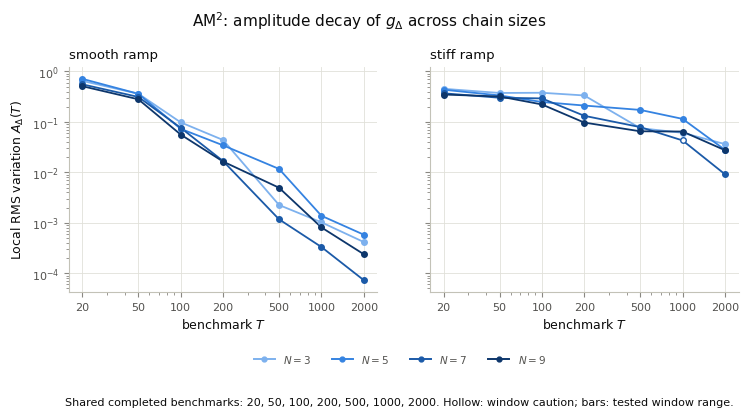

In [18]:
def component_all_N_figure(component_index, symbol, filename, ylim):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, axes = plt.subplots(1, 2, figsize=(7.7, 4.1), sharey=True)
        fig.subplots_adjust(left=.11, right=.98, bottom=.29, top=.84, wspace=.17)
        shown = []
        for N in NS:
            color = N_colors[N]
            visible = False
            for ax, s in zip(axes, SCHEDULES):
                y = PBD.component_curve(windows[N], s, component_index)
                if np.isfinite(PBD.display_curve(y, display_T)).any():
                    PBD.draw_estimates(ax, y, windows[N], s, color, display_T, component=component_index)
                    visible = True
            if visible:
                shown.append(Line2D([], [], color=color, marker="o", ms=3.5, label=f"$N={N}$"))
        for ax, s in zip(axes, SCHEDULES):
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(*xlimits)
            ax.set_ylim(*ylim)
            ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
            ax.xaxis.set_minor_formatter(NullFormatter())
            F.finish(ax, "benchmark $T$", title=F.SCHEDULE_LABEL[s], legend=False)
        axes[0].set_ylabel(f"Local RMS variation $A_{{{symbol}}}(T)$")
        fig.legend(handles=shown, loc="lower center", bbox_to_anchor=(.54, .09), ncol=len(NS))
        fig.suptitle(f"$\\mathrm{{AM}}^2$: amplitude decay of $g_{{{symbol}}}$ across chain sizes", y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range.")
        fig.text(.54, .015, footer, ha="center", fontsize=8)
        save(fig, FIGS / filename)


component_all_N_figure(1, r"\Delta", "grad_benchmark_decay_chains_Delta_AM2.pdf", ylimits[1])


wrote grad_benchmark_decay_chains_Omega_AM2.pdf


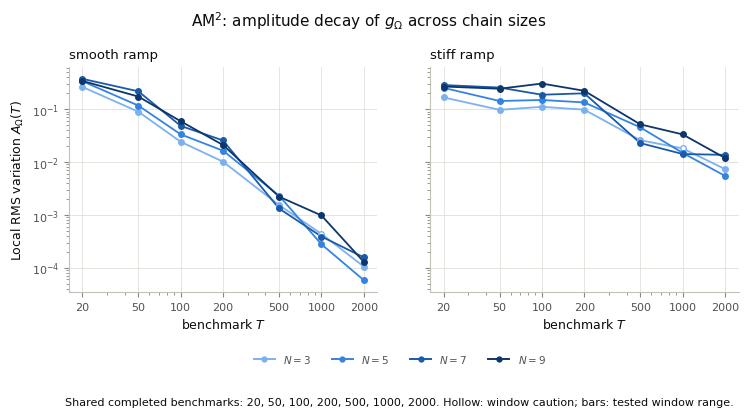

In [19]:
component_all_N_figure(0, r"\Omega", "grad_benchmark_decay_chains_Omega_AM2.pdf", ylimits[0])


## 4 & 5. All-$N$ amplitude decay, smooth and stiff superposed

Same data and axes as figures 2/3, but smooth and stiff share one panel per
component instead of separate subplots: smooth stays a solid line with
circle markers, stiff becomes a dashed line with x markers, so the two
schedules are distinguishable without needing color for that purpose (color
is already spent on $N$). The window-range error bars (stiff only, per the
audit scope) and the shared $y$-limits from figures 2/3 are unchanged.


wrote grad_benchmark_decay_chains_Delta_merged_AM2.pdf


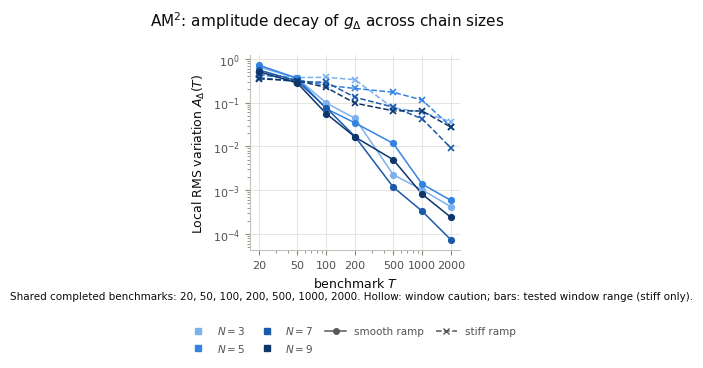

In [20]:
def draw_estimates_styled(ax, values, windows, schedule, color, benchmarks, component=None):
    """Like PBD.draw_estimates, but smooth/stiff are told apart by line/marker
    style (solid circle vs dashed x) instead of by being on separate axes."""
    x = np.asarray(PBD.BENCHMARKS)
    y = PBD.display_curve(values, benchmarks)
    finite = np.isfinite(y)
    limited = np.array([T in windows and PBD.window_caution(windows[T], schedule, component)
                        for T in PBD.BENCHMARKS])
    ls = "-" if schedule == "smooth" else "--"
    marker = "o" if schedule == "smooth" else "x"
    ax.plot(x, y, ls, color=color, lw=1.1)
    if schedule == "stiff":
        for i, T in enumerate(PBD.BENCHMARKS):
            if not finite[i] or "window_audit" not in windows.get(T, {}):
                continue
            record = windows[T]["window_audit"]["records"][0]
            bounds = (np.array(record["component_range"])[:, component] if component is not None
                      else np.array(record["centered_range"]))
            ax.errorbar(T, y[i], yerr=np.array([[max(0., y[i] - bounds[0])],
                                                [max(0., bounds[1] - y[i])]]),
                        fmt="none", ecolor=color, elinewidth=1., capsize=3, alpha=.8, zorder=3)
    # "x" has no fillable face, so the hollow/filled window-caution distinction
    # only shows for smooth's circles; stiff keeps the same marker either way.
    for mask, face in ((finite & ~limited, color), (finite & limited, "white")):
        ax.plot(x[mask], y[mask], marker, color=color,
                markerfacecolor=face if marker == "o" else color,
                markeredgewidth=1.2, ms=5 if marker == "x" else 4, zorder=4)


def component_all_N_figure_merged(component_index, symbol, filename, ylim):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, ax = plt.subplots(figsize=(3., 3.))
        fig.subplots_adjust(left=.19, right=.97, bottom=.30, top=.90)
        shown = []
        for N in NS:
            color = N_colors[N]
            visible = False
            for s in SCHEDULES:
                y = PBD.component_curve(windows[N], s, component_index)
                if np.isfinite(PBD.display_curve(y, display_T)).any():
                    draw_estimates_styled(ax, y, windows[N], s, color, display_T, component=component_index)
                    visible = True
            if visible:
                shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=f"$N={N}$"))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(*xlimits)
        ax.set_ylim(*ylim)
        ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
        ax.xaxis.set_minor_formatter(NullFormatter())
        F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$", legend=False)
        style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                          Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
        fig.legend(handles=shown + style_handles, loc="lower center",
                   bbox_to_anchor=(.58, -.20), ncol=4, columnspacing=1.1)
        fig.suptitle(f"$\\mathrm{{AM}}^2$: amplitude decay of $g_{{{symbol}}}$ across chain sizes", y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range (stiff only).")
        fig.text(.58, .015, footer, ha="center", fontsize=7.5)
        fig.tight_layout()
        save(fig, FIGS / filename)


component_all_N_figure_merged(1, r"\Delta", "grad_benchmark_decay_chains_Delta_merged_AM2.pdf", ylimits[1])


wrote grad_benchmark_decay_chains_Omega_merged_AM2.pdf


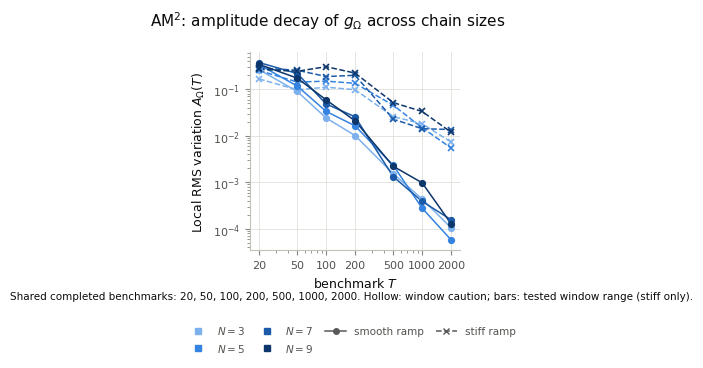

In [21]:
component_all_N_figure_merged(0, r"\Omega", "grad_benchmark_decay_chains_Omega_merged_AM2.pdf", ylimits[0])


## 6. Figures 4 and 5 side by side

Same panels as figures 4 and 5 (smooth/stiff already superposed by
line/marker style within each), just placed together as one two-panel
figure instead of two separate files. Color still encodes $N$ with the same
blue ramp in both panels -- $\Delta$ and $\Omega$ are told apart by the
panel, not by color.


wrote grad_benchmark_decay_chains_both_AM2.pdf


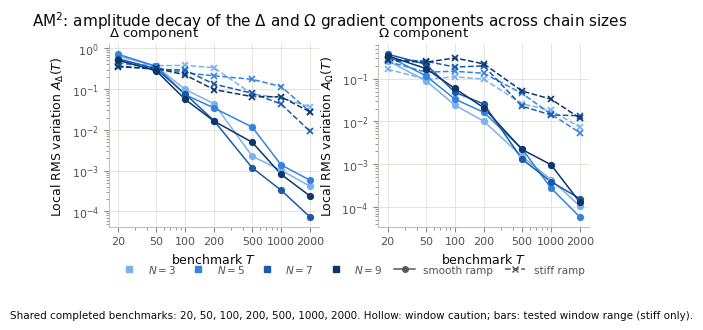

In [27]:
def two_component_figure(filename):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, axes = plt.subplots(1, 2, figsize=(5.4, 3.2))
        fig.subplots_adjust(left=.09, right=.98, bottom=.30, top=.87, wspace=.28)
        shown = []
        for ax, component_index, symbol, ylim in ((axes[0], 1, r"\Delta", ylimits[1]),
                                                   (axes[1], 0, r"\Omega", ylimits[0])):
            for N in NS:
                color = N_colors[N]
                visible = False
                for s in SCHEDULES:
                    y = PBD.component_curve(windows[N], s, component_index)
                    if np.isfinite(PBD.display_curve(y, display_T)).any():
                        draw_estimates_styled(ax, y, windows[N], s, color, display_T, component=component_index)
                        visible = True
                if visible and ax is axes[0]:
                    shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=f"$N={N}$"))
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(*xlimits)
            ax.set_ylim(*ylim)
            ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
            ax.xaxis.set_minor_formatter(NullFormatter())
            F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$",
                     title=f"${symbol}$ component", legend=False)
        style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                          Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
        fig.legend(handles=shown + style_handles, loc="lower center",
                   bbox_to_anchor=(.54, .12), ncol=len(shown) + 2, columnspacing=1.1)
        fig.suptitle(r"$\mathrm{AM}^2$: amplitude decay of the $\Delta$ and $\Omega$ gradient components across chain sizes",
                     y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range (stiff only).")
        fig.text(.54, .015, footer, ha="center", fontsize=7.5)
        save(fig, FIGS / filename)


two_component_figure("grad_benchmark_decay_chains_both_AM2.pdf")


## Effect of finite $\beta$

Earlier (in the theory behind figures 2/3) we derived the $O(1)$ deviation
caused by imperfect ground-state preparation at finite evolution time $T$:
an $O(1)$-in-$T$ bias appears whenever the schedule's first time-derivative
is discontinuous, which is exactly the stiff-schedule case. That derivation
was for the ideal $\beta\to0$ limit. Here we work out what changes at
**finite** $\beta$, since it is finite $\beta$ (not $\beta\to0$) that is
actually simulated. The result: at finite $\beta$, the $O(1)$ deviation
itself starts decaying in $T$, at a rate proportional to $1/(\beta T)$ --
which is exactly the decaying stiff-schedule oscillation seen for $N=1$
above, not something the $\beta\to0$ theory predicts.

**Derivation.** Start from a general term of the form
$R(\beta)=\frac{1}{T}e^{iT\gamma(\theta,\ \chi_\nu=\beta\epsilon_\nu)}$. In
QEP at finite $\beta$, the finite-difference construction of the gradient
produces terms of the form $\bigl(R(\beta)-R(0)\bigr)/\beta$:

$$
\begin{split}
\frac{R(\beta) - R(0)}{\beta} &= \frac{1}{\beta T} \left( e^{iT \gamma(\theta,\beta \epsilon_\nu)} - e^{iT \gamma(\theta,0)} \right) \\
&\approx \frac{1}{\beta T} \left( e^{iT (\gamma(\theta,0) + \beta \sum_\nu \partial_{\chi_\nu}\gamma(\theta, 0) \epsilon_\nu)} - e^{iT \gamma(\theta,0)} \right) \\
&= \frac{1}{\beta T} e^{iT (\gamma(\theta,\beta \epsilon_\nu) + \frac{\beta K}{2})}\, 2i \sin \frac{\beta K T}{2} \\
&= \frac{\sin\frac{\beta K T}{2}}{\frac{\beta K T}{2}}\; iK\, e^{iT (\gamma(\theta,\beta \epsilon_\nu) + \frac{\beta K}{2})}
\end{split}
$$

where $K = \sum_\nu \partial_{\chi_\nu}\gamma(\theta, 0)\, \epsilon_\nu$.

**Reading the result.** The finite-$\beta$ correction is the ideal
oscillating term multiplied by a $\mathrm{sinc}$ envelope,
$\mathrm{sinc}(\beta K T/2) = \sin(\beta KT/2)/(\beta KT/2)$, whose amplitude
decays as $2/(\beta T)$ for large $T$. As $\beta\to0$ this envelope flattens
toward 1 over any fixed $T$ range -- the damping becomes slower and
eventually disappears, recovering the non-decaying $O(1)$ stiff-schedule
bias that the $\beta=0$ theory predicts. In the exact $O(1)$-bias expression,
the $T$-growing term comes from derivatives of pieces like
$B_{n0}\,e^{-iT\tilde\gamma_n(\tau,0,\theta,\xi)}$; at finite $\beta$ each
such piece is replaced by the damped form derived above. Because the decay
rate is itself $\propto 1/\beta$, smaller $\beta$ delays the onset of
decay -- but for any fixed finite $\beta$, this slow $\mathrm{sinc}$ decay
eventually dominates the deviation at large enough $T$, and only vanishes
entirely in the strict $\beta=0$ limit.

This is the mechanism behind the decaying stiff-schedule deviation seen for
$N=1$: it is a finite-$\beta$ artifact of the estimator, not a property of
the ideal $\beta\to0$ bias. The smooth schedule's deviation is smaller under
the same conditions throughout: it decays as $O(T^{-1})$ in the ideal
$\beta\to0$ limit, and as $O(T^{-2}/\beta)$ at finite $\beta$ -- an extra
power of $T$ faster than the stiff case in both regimes.


## 7. Raw oscillation at $N=3$: $\beta=0.1$ vs $\beta=0.01$

Computed at $\beta\in\{0.2,0.1,0.05,0.02,0.01\}$ (each its own directory,
`data/bias_benchmarks_deep_AM2_beta{beta}/`, same $(\Omega,\Delta)=(1.0,1.0)$
point, cost $\mathrm{AM}^2$, $N=3$), but only $\beta=0.1$ and $\beta=0.01$ are
drawn, to keep the comparison readable: does the stiff-schedule deviation
still decay once $\beta$ is $10\times$ smaller? One panel per
(component, schedule) pair, so each panel isolates one comparison. Dotted
horizontal lines are each $\beta$'s own $g_{\mathrm{ED}}$, which is itself
$\beta$-dependent (it is the finite-nudge exact-state estimator, not the
idealised $\beta\to0$ derivative).

**Caveat vs. the AM version.** This appendix was originally run at $N=1$ under
AM, where the $\beta\to0$ stiff bias is a clean, flat $O(1)$ baseline, so any
decay was unambiguously a finite-$\beta$ effect. $\mathrm{AM}^2$ has no such
system ($N=1$ is identically zero), so at $N=3$ the finite-$\beta$ damping sits
on top of the genuine $N$-dependent decay and the two must be separated by
their $\beta$-scaling rather than read off directly.


wrote grad_oscillation_beta_AM2_N3.pdf


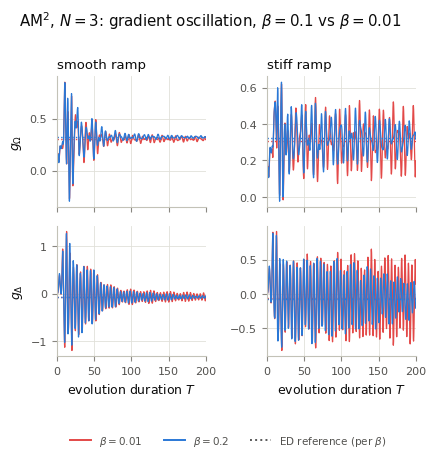

In [46]:
BETAS_ALL = (0.2, 0.1, 0.05, 0.02, 0.01)
BETAS_SHOW = (0.01, 0.2)
beta_colors = {0.2: "#2a78d6", 0.01: "#e34948"}

beta_raws = {beta: read(PAPER / "data" / f"bias_benchmarks_deep_AM2_beta{beta:g}" /
                        "benchmark_chain_N3_example_T200.npz") for beta in BETAS_SHOW}

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(2, 2, figsize=(4.6, 4.), sharex=True)
    for row, (j, symbol) in enumerate(((0, r"\Omega"), (1, r"\Delta"))):
        for col, schedule in enumerate(SCHEDULES):
            ax = axes[row, col]
            for beta in BETAS_SHOW:
                raw = beta_raws[beta]
                color = beta_colors[beta]
                ax.plot(raw["TL"], raw[f"g_{schedule}_AE"][:, j], color=color, lw=0.9,
                        label=rf"$\beta={beta:g}$")
                ax.axhline(raw["g_ED"][j], color=color, lw=1, ls=":")
            ax.set_xlim(0, 200)
            F.finish(ax, "evolution duration $T$" if row == 1 else None,
                     f"$g_{{{symbol}}}$" if col == 0 else None,
                     f"{F.SCHEDULE_LABEL[schedule]}" if row == 0 else None, legend=False)
    handles = [Line2D([], [], color=beta_colors[b], label=rf"$\beta={b:g}$") for b in BETAS_SHOW]
    handles.append(Line2D([], [], color="0.35", ls=":", label="ED reference (per $\\beta$)"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.54, -0.12), ncol=3)
    fig.suptitle(r"$\mathrm{AM}^2$, $N=3$: gradient oscillation, $\beta=0.1$ vs $\beta=0.01$", y=1.0)
    fig.tight_layout()
    save(fig, FIGS / "grad_oscillation_beta_AM2_N3.pdf")


## 8. Local amplitude decay vs $T$, across $\beta$ ($\mathrm{AM}^2$, $N=3$)

Same local-RMS-amplitude machinery as figures 2--6 (see
`Local_Amplitude_extraction.pdf` for the method), computed at all five
$\beta\in\{0.2,0.1,0.05,0.02,0.01\}$ for $N=3$ under $\mathrm{AM}^2$ instead of
across chain sizes. Same panel layout as figure 6 (one panel per component),
with $\beta$ taking the colour role $N$ had there (light = large $\beta$,
dark = small $\beta$) and reusing the same `draw_estimates_styled` (solid
circles = smooth, dashed x = stiff).

The theoretical expectation from the section above is that the stiff curves
separate by $\beta$ -- decay rate $\propto 1/(\beta T)$, so smaller $\beta$
decays later -- while the smooth curves, already decaying as a power of $T$,
are far less $\beta$-sensitive.


Shared completed benchmarks across all beta: [20, 50, 100, 200, 500, 1000, 2000]
wrote grad_benchmark_decay_beta_AM2_N3.pdf


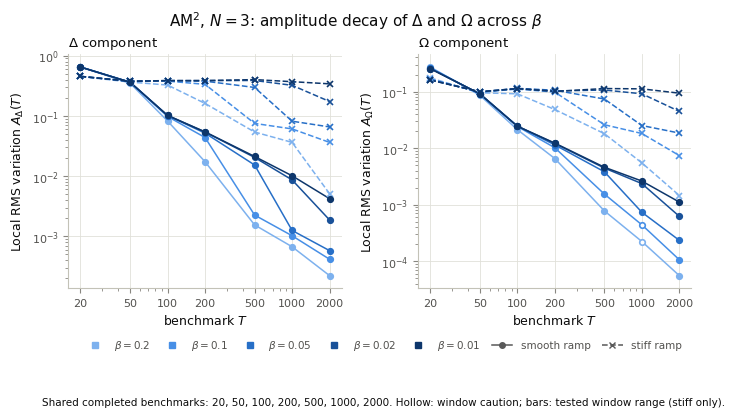

In [48]:
beta_windows = {}
PBD.NS = (3,)            # the beta sweep was only run at N=3
for beta in BETAS_ALL:
    w, _ = PBD.load_windows(PAPER / "data" / f"bias_benchmarks_deep_AM2_beta{beta:g}")
    beta_windows[beta] = w[3]

def display_T_for(windows_for_one_N):
    return [T for T in PBD.BENCHMARKS if T >= 20 and all(
        T in windows_for_one_N and PBD.numerically_resolved(windows_for_one_N[T], s)
        for s in SCHEDULES)]

beta_display_T = {beta: display_T_for(beta_windows[beta]) for beta in BETAS_ALL}
display_T_beta = sorted(set.intersection(*(set(v) for v in beta_display_T.values())))
xlimits_beta = (min(display_T_beta) / 1.25, max(display_T_beta) * 1.25)
print("Shared completed benchmarks across all beta:", display_T_beta)

def beta_shared_limits():
    limits = []
    for j in (0, 1):
        values = []
        for beta in BETAS_ALL:
            for s in SCHEDULES:
                y = PBD.display_curve(PBD.component_curve(beta_windows[beta], s, j), display_T_beta)
                values.extend(y[np.isfinite(y) & (y > 0)])
        lo, hi = np.log10([min(values), max(values)])
        pad = max(.12, .06 * (hi - lo))
        limits.append((float(10 ** (lo - pad)), float(10 ** (hi + pad))))
    return limits

PBD.NS = NS              # restore for any later re-run of figures 2-6
ylimits_beta = beta_shared_limits()
beta_ramp_colors = dict(zip(BETAS_ALL, F.ramp_colors(len(BETAS_ALL))))  # light=large beta, dark=small beta

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(1, 2, figsize=(7., 4.1))
    fig.subplots_adjust(left=.09, right=.98, bottom=.30, top=.87, wspace=.28)
    shown = []
    for ax, component_index, symbol, ylim in ((axes[0], 1, r"\Delta", ylimits_beta[1]),
                                               (axes[1], 0, r"\Omega", ylimits_beta[0])):
        for beta in BETAS_ALL:
            color = beta_ramp_colors[beta]
            windows_beta = beta_windows[beta]
            visible = False
            for s in SCHEDULES:
                y = PBD.component_curve(windows_beta, s, component_index)
                if np.isfinite(PBD.display_curve(y, display_T_beta)).any():
                    draw_estimates_styled(ax, y, windows_beta, s, color, display_T_beta, component=component_index)
                    visible = True
            if visible and ax is axes[0]:
                shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=rf"$\beta={beta:g}$"))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(*xlimits_beta)
        ax.set_ylim(*ylim)
        ax.set_xticks(display_T_beta, [f"{T:g}" for T in display_T_beta])
        ax.xaxis.set_minor_formatter(NullFormatter())
        F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$",
                 title=f"${symbol}$ component", legend=False)
    style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                      Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
    fig.legend(handles=shown + style_handles, loc="lower center",
               bbox_to_anchor=(.54, .12), ncol=len(shown) + 2, columnspacing=1.1)
    fig.suptitle(r"$\mathrm{AM}^2$, $N=3$: amplitude decay of $\Delta$ and $\Omega$ across $\beta$", y=.98, fontsize=11)
    footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T_beta) +
              ". Hollow: window caution; bars: tested window range (stiff only).")
    fig.text(.54, .015, footer, ha="center", fontsize=7.5)
    save(fig, FIGS / "grad_benchmark_decay_beta_AM2_N3.pdf")


## 7′ & 8′. The same two figures at $N=1$ — necessarily the **AM** cost

Figures 7 and 8 above had to move to $N=3$ because $\mathrm{AM}^2$ has no
$N=1$ system to measure: for a single atom $\mathrm{AM}=\sigma^z$, so
$\mathrm{AM}^2=\mathbb{1}$ and the gradient is identically zero. These primed
versions therefore reuse the **linear AM** cost at $N=1$
(`data/bias_benchmarks_deep_beta{beta}/`, `cost='AM'`, same
$(\Omega,\Delta)=(1.0,1.0)$ point and the same five $\beta$), where $N=1$ is
perfectly well defined.

Scientifically this is the *cleaner* demonstration of the finite-$\beta$
mechanism, which is why it is kept: at $N=1$ under AM the $\beta\to0$ stiff
bias is a flat $O(1)$ baseline, so any decay is unambiguously the
finite-$\beta$ $\mathrm{sinc}$ damping rather than the genuine $N$-dependent
decay that is mixed in at $N=3$. Figures 7/8 (AM$^2$, $N=3$) and 7′/8′
(AM, $N=1$) are the same measurement on the two different cost operators.


wrote grad_oscillation_beta_N1.pdf


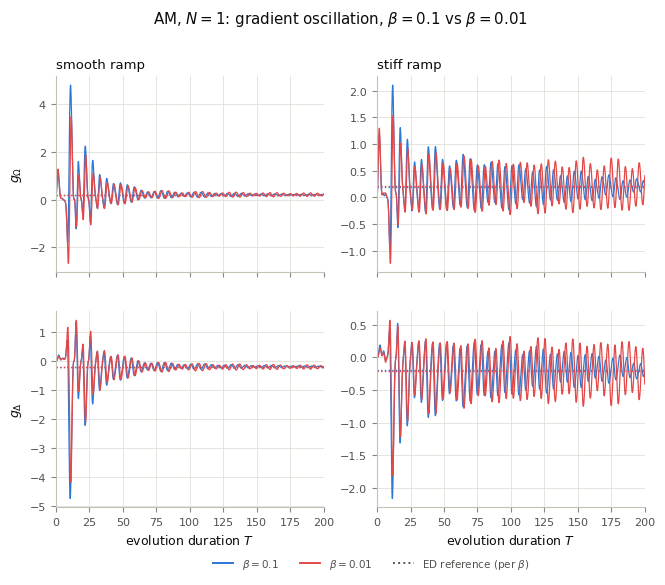

In [25]:
# Figure 7' -- identical to figure 7, but AM cost at N=1.
beta_raws_N1 = {beta: read(PAPER / "data" / f"bias_benchmarks_deep_beta{beta:g}" /
                           "benchmark_chain_N1_example_T200.npz") for beta in BETAS_SHOW}

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(2, 2, figsize=(7.6, 5.6), sharex=True)
    for row, (j, symbol) in enumerate(((0, r"\Omega"), (1, r"\Delta"))):
        for col, schedule in enumerate(SCHEDULES):
            ax = axes[row, col]
            for beta in BETAS_SHOW:
                raw = beta_raws_N1[beta]
                color = beta_colors[beta]
                ax.plot(raw["TL"], raw[f"g_{schedule}_AE"][:, j], color=color, lw=0.9)
                ax.axhline(raw["g_ED"][j], color=color, lw=1, ls=":")
            ax.set_xlim(0, 200)
            F.finish(ax, "evolution duration $T$" if row == 1 else None,
                     f"$g_{{{symbol}}}$" if col == 0 else None,
                     f"{F.SCHEDULE_LABEL[schedule]}" if row == 0 else None, legend=False)
    handles = [Line2D([], [], color=beta_colors[b], label=rf"$\beta={b:g}$") for b in BETAS_SHOW]
    handles.append(Line2D([], [], color="0.35", ls=":", label="ED reference (per $\\beta$)"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.54, -0.02), ncol=3)
    fig.suptitle(r"$\mathrm{AM}$, $N=1$: gradient oscillation, $\beta=0.1$ vs $\beta=0.01$", y=1.0)
    save(fig, FIGS / "grad_oscillation_beta_N1.pdf")


Shared completed benchmarks across all beta (AM, N=1): [20, 50, 100, 200, 500, 1000, 2000]
wrote grad_benchmark_decay_beta_N1.pdf


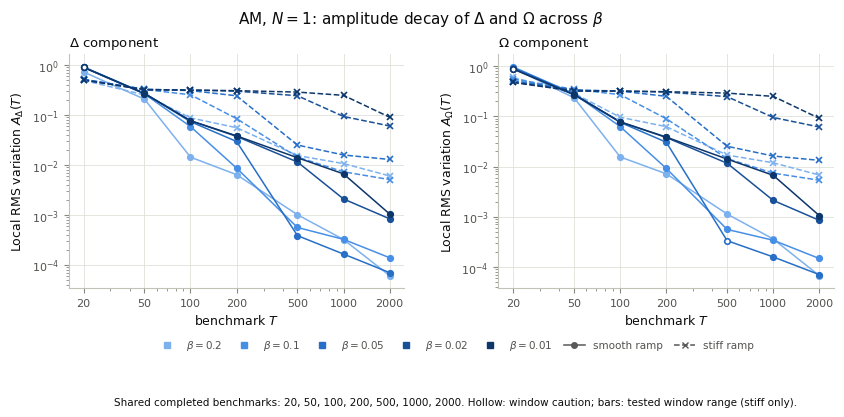

In [26]:
# Figure 8' -- identical to figure 8, but AM cost at N=1.
beta_windows_N1 = {}
PBD.NS = (1,)                      # the AM beta sweep was only run at N=1
for beta in BETAS_ALL:
    w, _ = PBD.load_windows(PAPER / "data" / f"bias_benchmarks_deep_beta{beta:g}")
    beta_windows_N1[beta] = w[1]
PBD.NS = NS                        # restore

beta_display_T_N1 = {b: display_T_for(beta_windows_N1[b]) for b in BETAS_ALL}
display_T_N1 = sorted(set.intersection(*(set(v) for v in beta_display_T_N1.values())))
xlimits_N1 = (min(display_T_N1) / 1.25, max(display_T_N1) * 1.25)
print("Shared completed benchmarks across all beta (AM, N=1):", display_T_N1)

ylimits_N1 = []
for j in (0, 1):
    vals = []
    for beta in BETAS_ALL:
        for s in SCHEDULES:
            y = PBD.display_curve(PBD.component_curve(beta_windows_N1[beta], s, j), display_T_N1)
            vals.extend(y[np.isfinite(y) & (y > 0)])
    lo, hi = np.log10([min(vals), max(vals)])
    pad = max(.12, .06 * (hi - lo))
    ylimits_N1.append((float(10 ** (lo - pad)), float(10 ** (hi + pad))))

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.1))
    fig.subplots_adjust(left=.09, right=.98, bottom=.30, top=.87, wspace=.28)
    shown = []
    for ax, ci, symbol, ylim in ((axes[0], 1, r"\Delta", ylimits_N1[1]),
                                 (axes[1], 0, r"\Omega", ylimits_N1[0])):
        for beta in BETAS_ALL:
            color = beta_ramp_colors[beta]
            wb = beta_windows_N1[beta]
            visible = False
            for s in SCHEDULES:
                y = PBD.component_curve(wb, s, ci)
                if np.isfinite(PBD.display_curve(y, display_T_N1)).any():
                    draw_estimates_styled(ax, y, wb, s, color, display_T_N1, component=ci)
                    visible = True
            if visible and ax is axes[0]:
                shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=rf"$\beta={beta:g}$"))
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(*xlimits_N1); ax.set_ylim(*ylim)
        ax.set_xticks(display_T_N1, [f"{T:g}" for T in display_T_N1])
        ax.xaxis.set_minor_formatter(NullFormatter())
        F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$",
                 title=f"${symbol}$ component", legend=False)
    style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                     Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
    fig.legend(handles=shown + style_handles, loc="lower center",
               bbox_to_anchor=(.54, .12), ncol=len(shown) + 2, columnspacing=1.1)
    fig.suptitle(r"$\mathrm{AM}$, $N=1$: amplitude decay of $\Delta$ and $\Omega$ across $\beta$",
                 y=.98, fontsize=11)
    fig.text(.54, .015, "Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T_N1) +
             ". Hollow: window caution; bars: tested window range (stiff only).",
             ha="center", fontsize=7.5)
    save(fig, FIGS / "grad_benchmark_decay_beta_N1.pdf")
